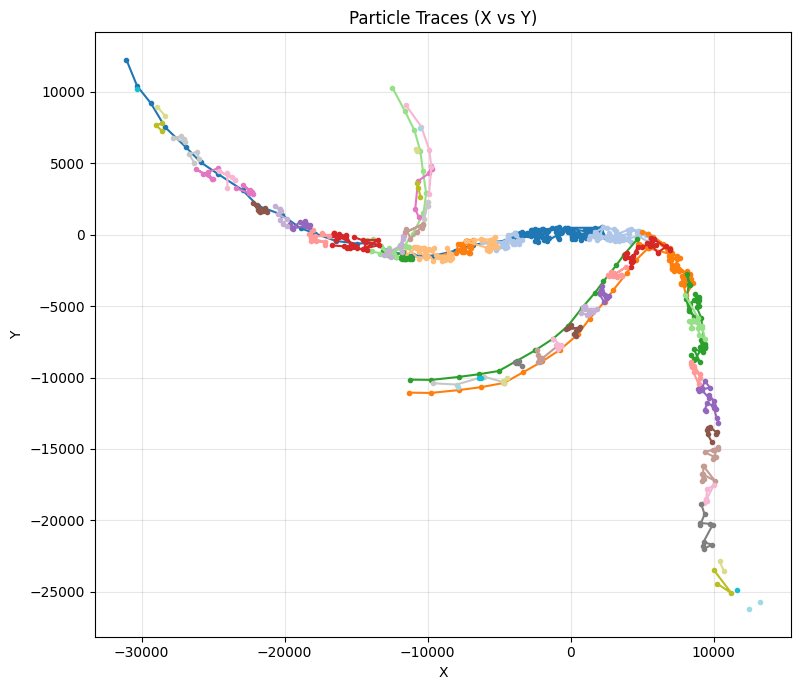

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

df = pd.read_csv("input/Traces(16).csv", header=None, names=["particle", "time", "x", "y"])

particles = df["particle"].unique()
colors = cm.tab20(np.linspace(0, 1, len(particles)))

fig, ax1 = plt.subplots(figsize=(10, 7))

# Spatial traces
for i, pid in enumerate(particles):
    p = df[df["particle"] == pid]
    ax1.plot(p["x"], p["y"], "-o", color=colors[i], markersize=3, label=f"Particle {pid}")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_title("Particle Traces (X vs Y)")
#ax1.legend(fontsize=7, loc="best")
ax1.set_aspect("equal")
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_190772/2033852026.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


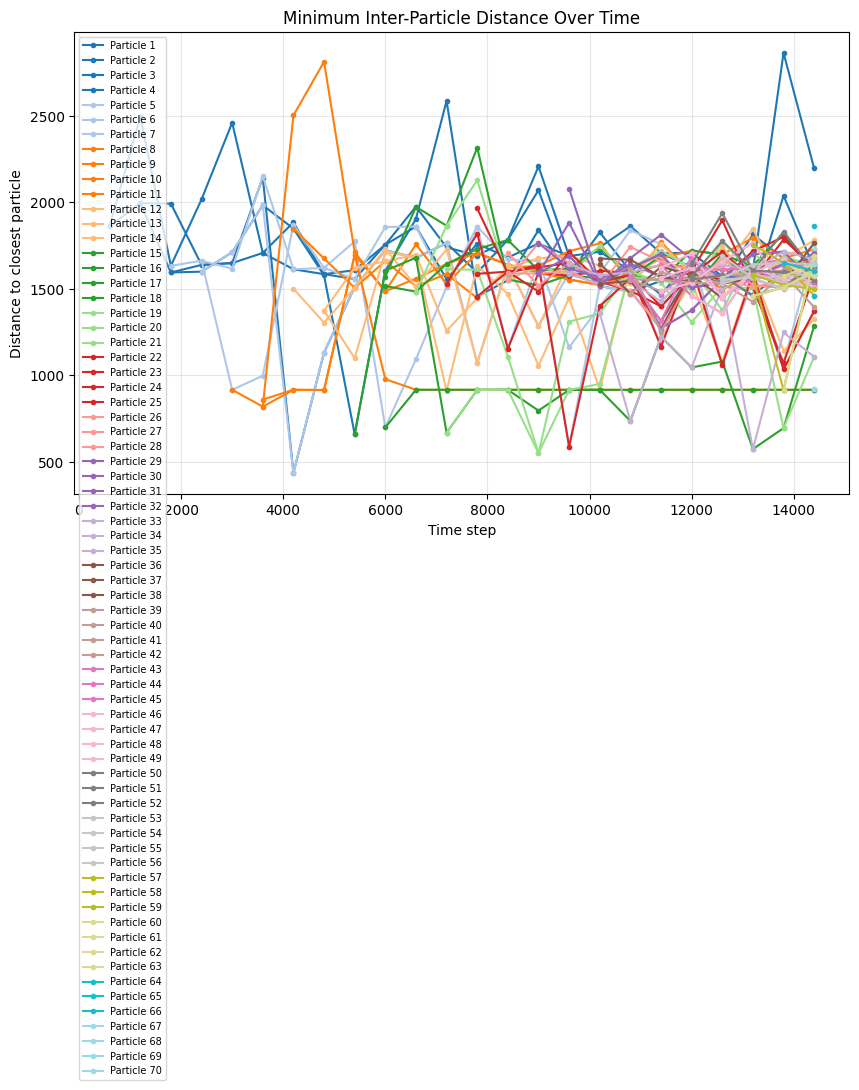

In [27]:
from scipy.spatial.distance import cdist

# For each time step, compute distance to closest other particle
min_distances = []

for t in df["time"].unique():
    snapshot = df[df["time"] == t]
    coords = snapshot[["x", "y"]].values
    if len(coords) > 1:
        dist_matrix = cdist(coords, coords)
        np.fill_diagonal(dist_matrix, np.inf)
        closest = dist_matrix.min(axis=1)
    else:
        closest = [np.nan]
    for pid, d in zip(snapshot["particle"], closest):
        min_distances.append({"particle": pid, "time": t, "min_dist": d})

df_dist = pd.DataFrame(min_distances)

# Plot min distance over time for each particle
fig, ax = plt.subplots(figsize=(10, 6))
for i, pid in enumerate(df_dist["particle"].unique()):
    p = df_dist[df_dist["particle"] == pid]
    ax.plot(p["time"], p["min_dist"], "-o", color=colors[i], markersize=3, label=f"Particle {pid}")

ax.set_xlabel("Time step")
ax.set_ylabel("Distance to closest particle")
ax.set_title("Minimum Inter-Particle Distance Over Time")
ax.legend(fontsize=7, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

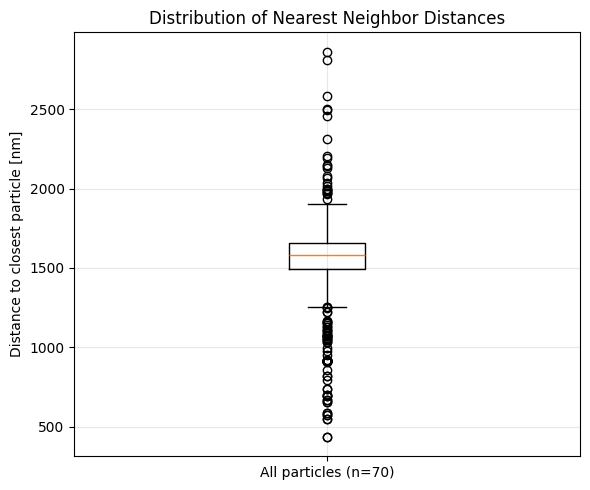

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(df_dist["min_dist"].dropna(), vert=True, showfliers=True)
ax.set_ylabel("Distance to closest particle [nm]")
ax.set_title("Distribution of Nearest Neighbor Distances")
ax.set_xticklabels(["All particles (n=70)"])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()